# **Evolutionary Computing, lab 7 - Report**

**Authors**:
* **Kuba Czech**, 156035
* **Wojciech Nagórka**, 156045

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **1. Description of the problem** ##

We are given a set of nodes, each defined by its x and y coordinates and an associated cost. The task is to select exactly half of the nodes (rounded up if the number is odd) and construct a Hamiltonian cycle that visits each selected node exactly once and returns to the starting node. The objective is to minimize the total sum of both the path length (computed using rounded Euclidean distances between nodes) and the costs of the selected nodes.

## **2. Pseudocode of implemented algorithms** ##

### **2.1. Data**
**Input:**
- $n$: total number of nodes  
- $nodes[i] = (x_i, y_i, cost_i)$ for $i \in [0, n-1]$: array with all nodes
- $distanceMatrix[i][j] = \text{round}\!\left(\sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}\right)$: euclidean distance between i-th and j-th node
- $NUM\_OF\_ITERATIONS$: number of basic local search iterations
- $TIME\_LIMIT$: upper limit of running time for ILS algorithm

**Output:**
- $route$: list of nodes forming a closed Hamiltonian cycle  
- $totalCost = \text{distance cost} + \text{node costs}$

### **2.2. Multiple Start Local Search**

```text
function MultipleStartLocalSearch():
    best_route = empty list

    for 1, 2, ..., NUM_of_ITERATIONS:
        route ← getRandomRoute()
        route ← SteepestDescent(route)
        if cost(best_route) < cost(current_route) or best_route is empty:
            best_route ← route
    return best_route

### **2.3. Large Neighborhood Search with Local Search**

```text
function LargeNeighborhoodSearchWithLocalSearch():
    initialRoute ← getRandomRoute()
    route ← LocalSearch(initialRoute)

    while total_time < TIME_LIMIT:
        destroyedRoute ← destroy(route)
        newRoute ← repair(destroyedRoute)
        
        newRoute ← LocalSearch(newRoute)
        if cost(newRoute) < cost(route):
            route = newRoute
    
    return route

### **2.4. Large Neighborhood Search without Local Search**

```text
function LargeNeighborhoodSearchWithoutLocalSearch():
    route ← getRandomRoute()

    while total_time < TIME_LIMIT:
        destroyedRoute ← destroy(route)
        newRoute ← repair(destroyedRoute)
        
        if cost(newRoute) < cost(route):
            route = newRoute
    
    return route

### **2.5. Destroy function**

```text
function destroy(route):
    numberOfNodesToRemove ← 0.3 * size(route)

    for 1, 2, ..., numberOfNodesToRemove:
        randomIdx ← random integer between 0 and current size of route
        route.remove(randomIdx)
    
    return route

### **2.6. Repair function**

```text
function repair(route):
    regretWeight ← 0.5
    for nodeNumber in route:
        used[nodeNumber] ← true


    while size(route) < targetCount:
        bestNode, bestPos, bestScore ← -1, -1, -∞

        for each unused node j:
            deltas ← []
            for pos in 0 .. size(route):
                if pos == 0:
                    k ← route[0]
                    delta ← distance[j][k] + nodes[j].cost
                else if pos == size(route):
                    i ← route[last]
                    delta ← distance[i][j] + nodes[j].cost
                else:
                    i ← route[pos-1]
                    k ← route[pos]
                    delta ← distance[i][j] + distance[j][k] - distance[i][k] + nodes[j].cost
                deltas.add(delta)
            deltas ← sorted(deltas)
            bestΔ, secondΔ ← deltas[0], deltas[1]
            regret ← secondΔ - bestΔ
            score ← regretWeight * regret - (1 - regretWeight) * bestΔ

            if score > bestScore:
                bestScore ← score
                bestNode ← j
                bestPos ← position of bestΔ in deltas

        insert bestNode at bestPos in route
        used[bestNode] ← true

    route.add(route[0])
    return route
    


## **3. Results of computational experiments** ##

### **3.1. Stats** ###

#### **3.1.1. Instance A** 

In [66]:
stats_lab7 = pd.read_csv('evaluation/TSPA_stats.csv')
stats_lab6 = pd.read_csv('../lab6/evaluation/TSPA_stats.csv')

stats_greedy = pd.concat([
    pd.read_csv('../lab1/evaluation/TSPA_stats.csv'),
    pd.read_csv('../lab2/evaluation/TSPA_stats.csv')
    ], ignore_index=True).sort_values('min').head(1)

stats_greedy = stats_greedy[stats_greedy.method_name == 'weighted_regret_flexibleNN'].head(1)

stats_local = pd.concat([
    pd.read_csv('../lab5/evaluation/TSPA_stats.csv'),
    pd.read_csv('../lab4/evaluation/TSPA_stats.csv'), 
    pd.read_csv('../lab3/evaluation/TSPA_local_stats.csv')
    ], ignore_index=True)

stats_local = stats_local[stats_local.method_name.str.startswith('steepest')].sort_values('min').head(1)

In [67]:
stats_summary = pd.concat([
    stats_lab7,
    stats_lab6,
    stats_greedy,
    stats_local
    ], ignore_index=True)

stats_summary

,method_name,min,max,avg,sd
0,LNSWithLS,69288.0,70148.0,69882.00,230.94
1,LNSWithoutLS,69723.0,73580.0,71688.75,958.24
2,MSLS,70585.0,71825.0,71364.65,298.91
3,ILS,69152.0,69895.0,69471.40,229.85
4,weighted_regret_flexibleNN,70010.0,75452.0,72401.34,1409.01
5,steepest_edge_heuristic,69540.0,72546.0,70722.88,554.35


#### **3.1.2. Instance B** 

In [70]:
stats_lab7 = pd.read_csv('evaluation/TSPB_stats.csv')
stats_lab6 = pd.read_csv('../lab6/evaluation/TSPB_stats.csv')

stats_greedy = pd.concat([
    pd.read_csv('../lab1/evaluation/TSPB_stats.csv'),
    pd.read_csv('../lab2/evaluation/TSPB_stats.csv')
    ], ignore_index=True)

stats_greedy = stats_greedy[stats_greedy.method_name == 'weighted_regret_flexibleNN'].head(1)

stats_local = pd.concat([
    pd.read_csv('../lab5/evaluation/TSPB_stats.csv'),
    pd.read_csv('../lab4/evaluation/TSPB_stats.csv'), 
    pd.read_csv('../lab3/evaluation/TSPB_local_stats.csv')
    ], ignore_index=True)

stats_local = stats_local[stats_local.method_name.str.startswith('steepest')].sort_values('min').head(1)

In [72]:
stats_summary = pd.concat([
    stats_lab7,
    stats_lab6,
    stats_greedy,
    stats_local
    ], ignore_index=True)

stats_summary

,method_name,min,max,avg,sd
0,LNSWithLS,43545.0,44674.0,44042.00,310.05
1,LNSWithoutLS,43963.0,47556.0,45996.40,967.07
2,MSLS,44790.0,46322.0,45583.15,388.16
3,ILS,43477.0,44552.0,43859.30,316.47
4,weighted_regret_flexibleNN,44891.0,55247.0,47653.79,1764.00
5,steepest_edge_heuristic,44320.0,51431.0,46347.17,1450.58


### **3.2. Times** ###

Upper limit of time of computation for both types of Large Neighbor Search comes from averaging all times of MSLS runs. In all cases average running time will be the same, so there is no need to write times twice.

In [73]:
time_a = pd.read_csv('evaluation/TSPA_times.csv').values[0][1]
time_b = pd.read_csv('evaluation/TSPB_times.csv').values[0][1]

times = pd.DataFrame({'instance': ['TSPA', 'TSPB'], 'avg_time_ms': [time_a, time_b]})
times.rename(columns={'avg_time_ms': 'average time of one iteration (ms)'}, inplace=True)
times

,instance,average time of one iteration (ms)
0,TSPA,8017
1,TSPB,8062


### **3.3. Number of runs for ILS**

#### **3.3.1. Tabular results**

In [74]:
LNS_with_LS_nr_of_it_a = np.array(pd.read_csv('evaluation/iterations/TSPA_LNS_with_LS_iterations.csv', header=None).values).flatten()
LNS_no_LS_nr_of_it_a = np.array(pd.read_csv('evaluation/iterations/TSPA_LNS_without_LS_iterations.csv', header=None).values).flatten()

LNS_with_LS_nr_of_it_b = np.array(pd.read_csv('evaluation/iterations/TSPB_LNS_with_LS_iterations.csv', header=None).values).flatten()
LNS_no_LS_nr_of_it_b = np.array(pd.read_csv('evaluation/iterations/TSPB_LNS_without_LS_iterations.csv', header=None).values).flatten()

iterations = [('TSPA', 'LNS with LS', LNS_with_LS_nr_of_it_a), ('TSPA', 'LNS without LS', LNS_no_LS_nr_of_it_a),
              ('TSPB', 'LNS with LS', LNS_with_LS_nr_of_it_b), ('TSPB', 'LNS without LS', LNS_no_LS_nr_of_it_b)]

nr_of_iterations_summary = pd.DataFrame([
    {
        'instance': instance,
        'method': method,
        'min': np.min(nr_of_iterations),
        'max': np.max(nr_of_iterations),
        'avg': round(np.mean(nr_of_iterations))
    }
    for instance, method, nr_of_iterations in iterations
])
nr_of_iterations_summary

,instance,method,min,max,avg
0,TSPA,LNS with LS,620,681,656
1,TSPA,LNS without LS,708,742,728
2,TSPB,LNS with LS,641,692,665
3,TSPB,LNS without LS,729,758,741


#### **3.3.2. Histogram**

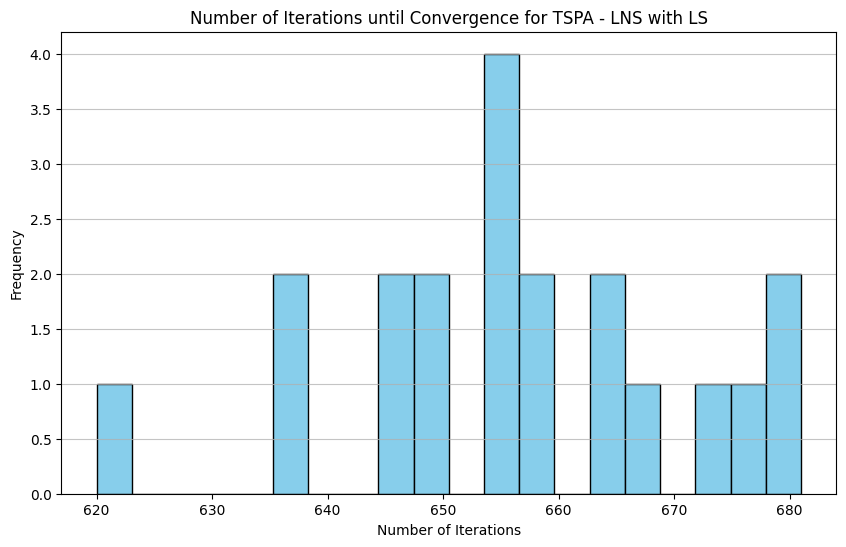

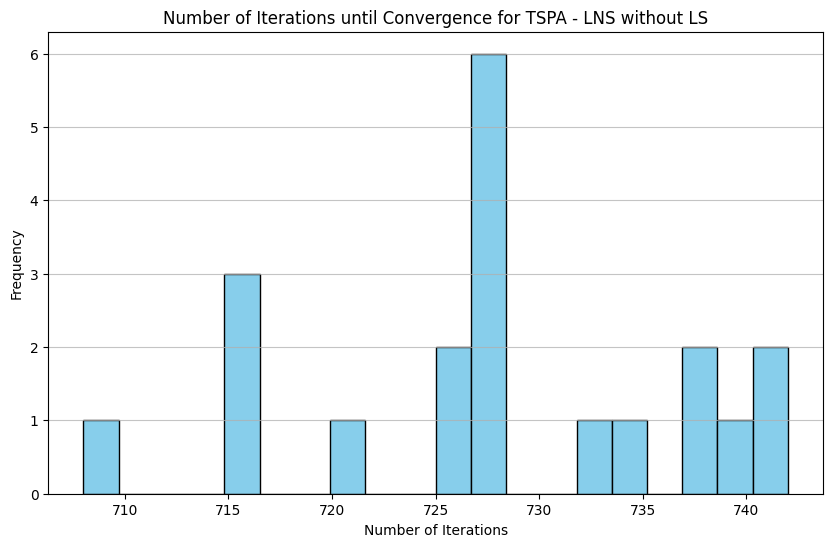

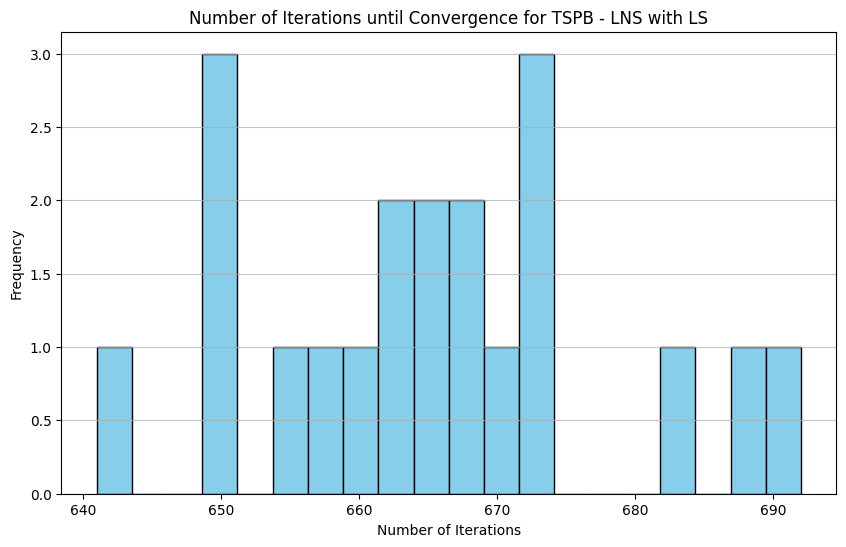

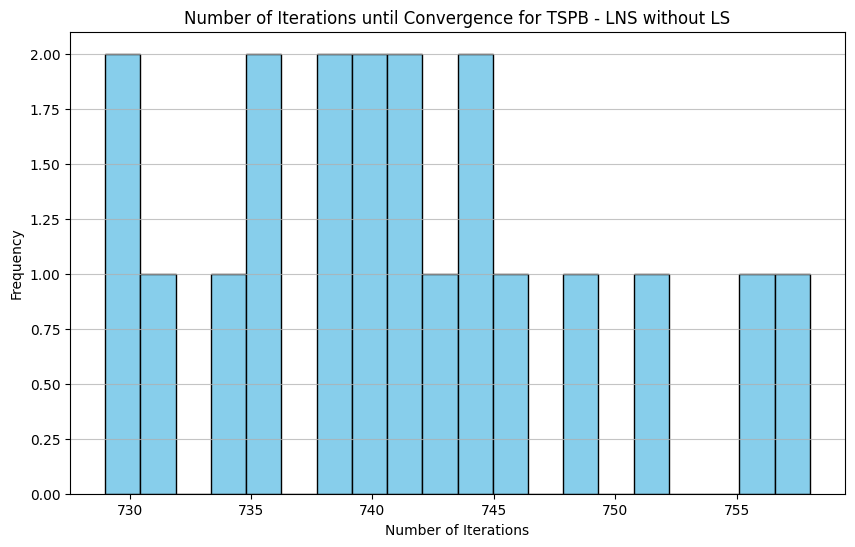

In [35]:
def plot_histogram(instance_name, nr_of_iterations):
    plt.figure(figsize=(10, 6))
    plt.hist(nr_of_iterations, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Number of Iterations until Convergence for {instance_name}')
    plt.xlabel('Number of Iterations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

for instance, method, nr_of_iterations in iterations:
    plot_histogram(f'{instance} - {method}', nr_of_iterations)

#### **3.3.3. Barchart**

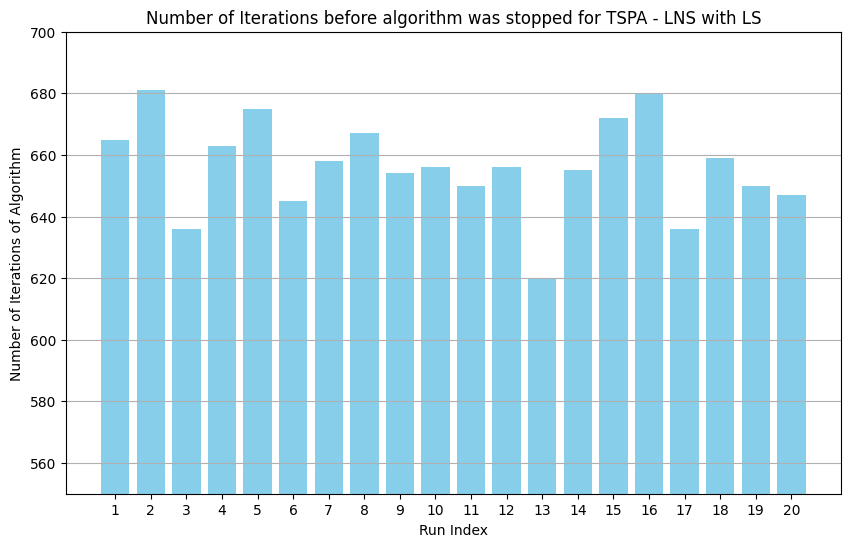

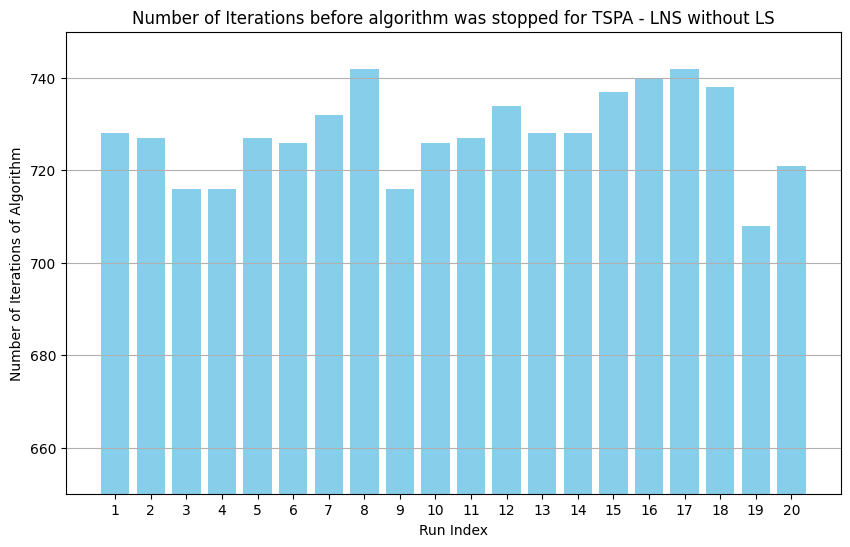

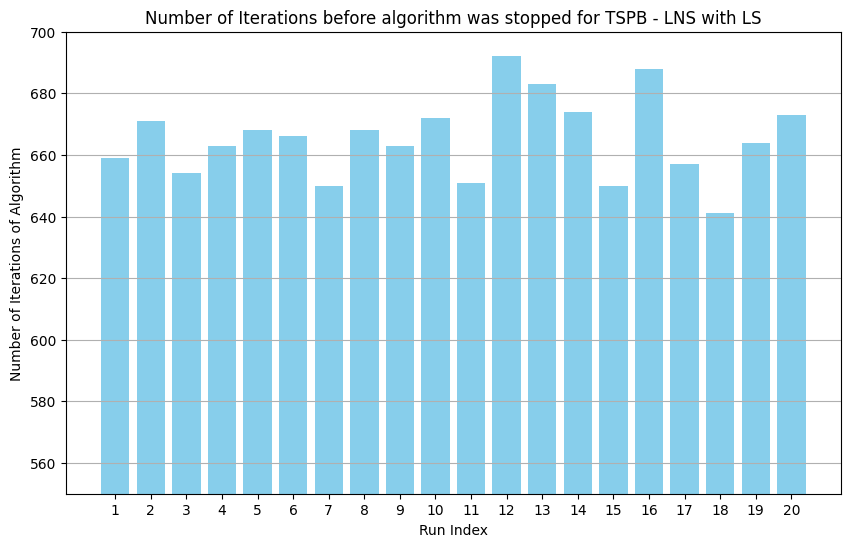

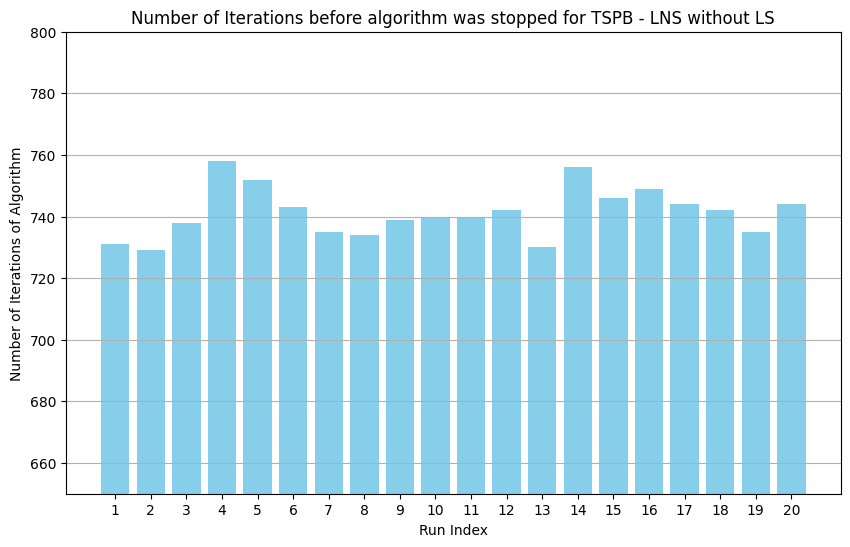

In [37]:
def plot_barchart(instance_name, nr_of_iterations):
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(nr_of_iterations)+1), nr_of_iterations, color='skyblue')
    
    plt.xlabel('Run Index')
    plt.ylabel('Number of Iterations of Algorithm')
    plt.title(f'Number of Iterations before algorithm was stopped for {instance_name}')
    lower_limit = (min(nr_of_iterations) - 50)// 50 * 50
    upper_limit = (max(nr_of_iterations) + 50)// 50 * 50
    plt.ylim(lower_limit, upper_limit)

    plt.xticks(range(1, len(nr_of_iterations)+1))
    plt.grid(axis='y')
    plt.show()

for instance, method, nr_of_iterations in iterations:
    plot_barchart(f'{instance} - {method}', nr_of_iterations)

## **4. 2D Visualization** ##

### **Reading TSP A and TSP B instances** ##

In [22]:
tsp_a = pd.read_csv('../data/TSPA.csv', sep=';', header=None)
tsp_a.columns = ['x', 'y', 'cost']

tsp_b = pd.read_csv('../data/TSPB.csv', sep=';', header=None)
tsp_b.columns = ['x', 'y', 'cost']

### **Reading files with best solutions** ##

In [23]:
tsp_a_LNS_with_LS = np.array(pd.read_csv('evaluation/results/TSPA_LNSWithLS.csv', sep=';', header=None).values).flatten()
tsp_a_LNS_no_LS = np.array(pd.read_csv('evaluation/results/TSPA_LNSWithoutLS.csv', sep=';', header=None).values).flatten()

In [24]:
tsp_b_LNS_with_LS = np.array(pd.read_csv('evaluation/results/TSPB_LNSWithLS.csv', sep=';', header=None).values).flatten()
tsp_b_LNS_no_LS = np.array(pd.read_csv('evaluation/results/TSPB_LNSWithoutLS.csv', sep=';', header=None).values).flatten()

In [25]:
def plot_tsp(tsp, solution, title):
    unused_nodes = np.array(set(tsp.index).difference(solution))
    X = tsp['x'].loc[solution].values
    Y = tsp['y'].loc[solution].values
    costs = tsp['cost'].loc[solution].values

    X_unused = tsp['x'].loc[unused_nodes].values
    Y_unused = tsp['y'].loc[unused_nodes].values
    costs_unused = tsp['cost'].loc[unused_nodes].values

    plt.figure(figsize=(15, 9))
    plt.scatter(X, Y, s=costs, color='red', alpha=0.4, label='Data points')
    plt.scatter(X_unused, Y_unused, s=costs_unused, color="grey", alpha=0.4, label="Unused nodes")
    plt.scatter(X, Y, color='blue')
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')

    plt.plot(X, Y, color='blue', linestyle='-', linewidth=2, label='Connecting line')

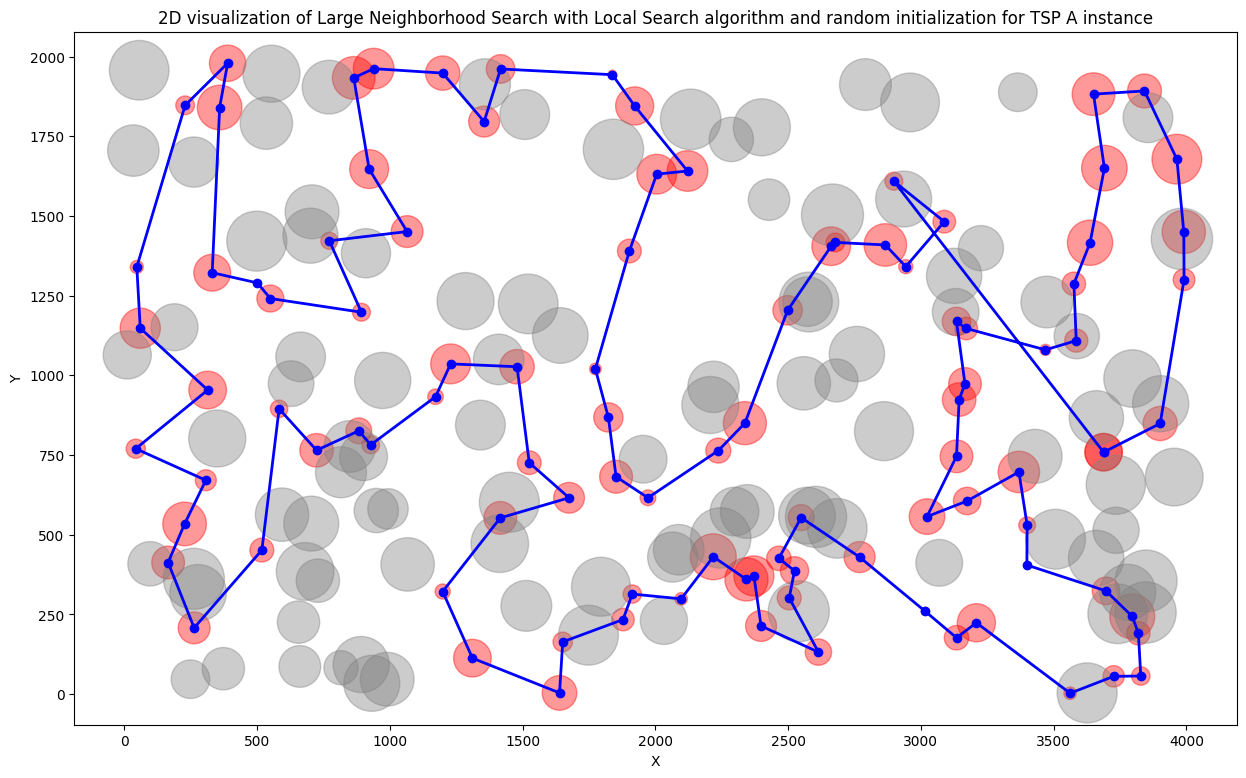

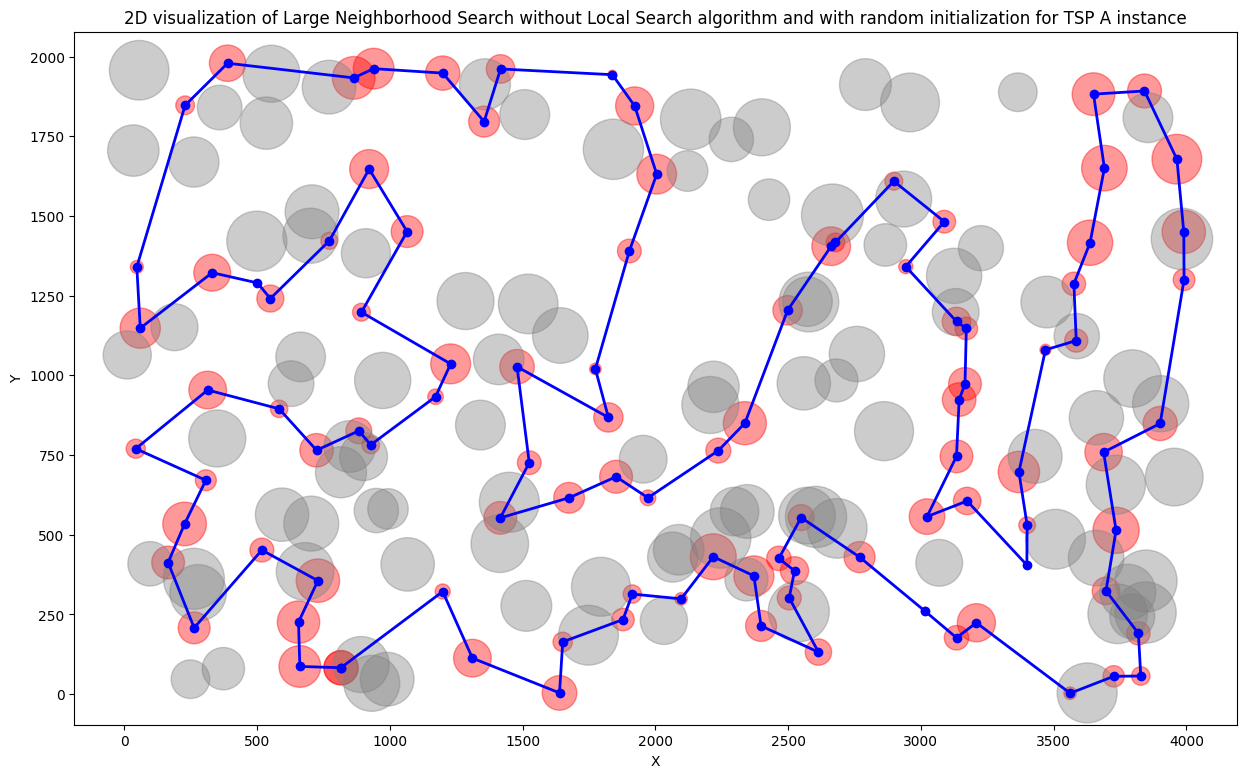

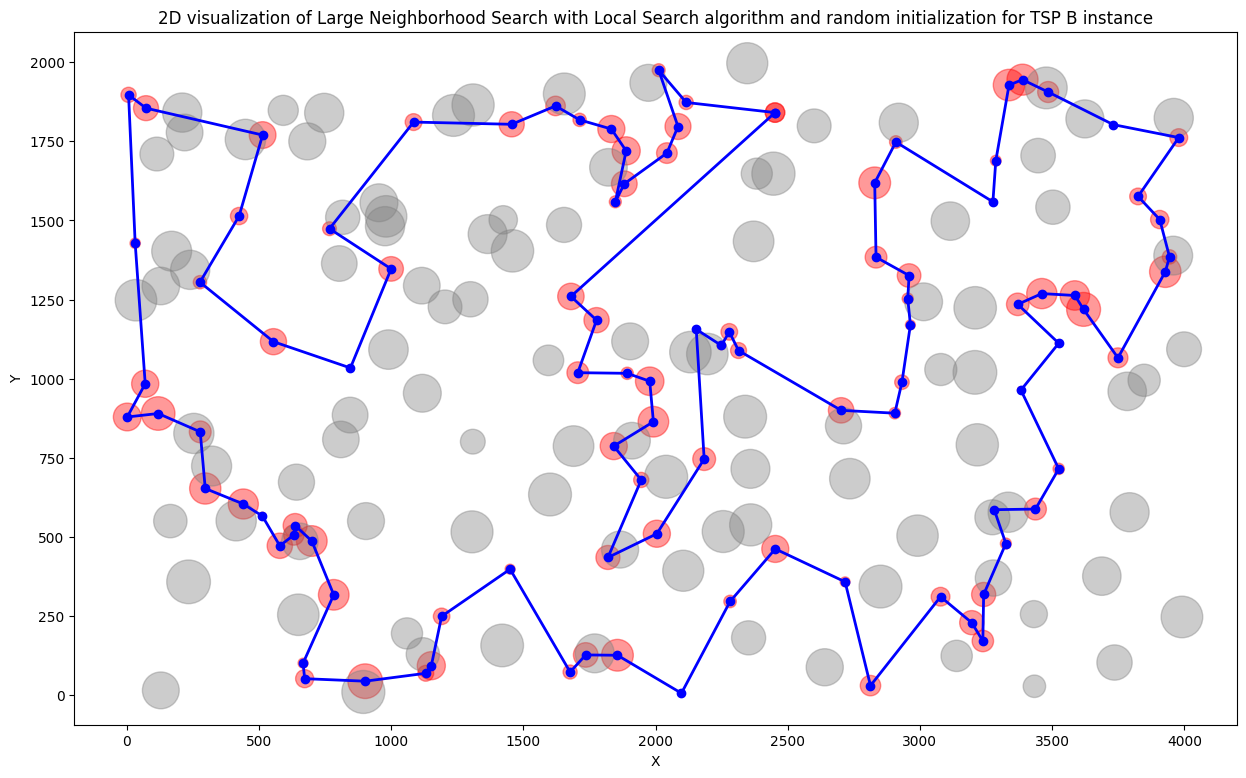

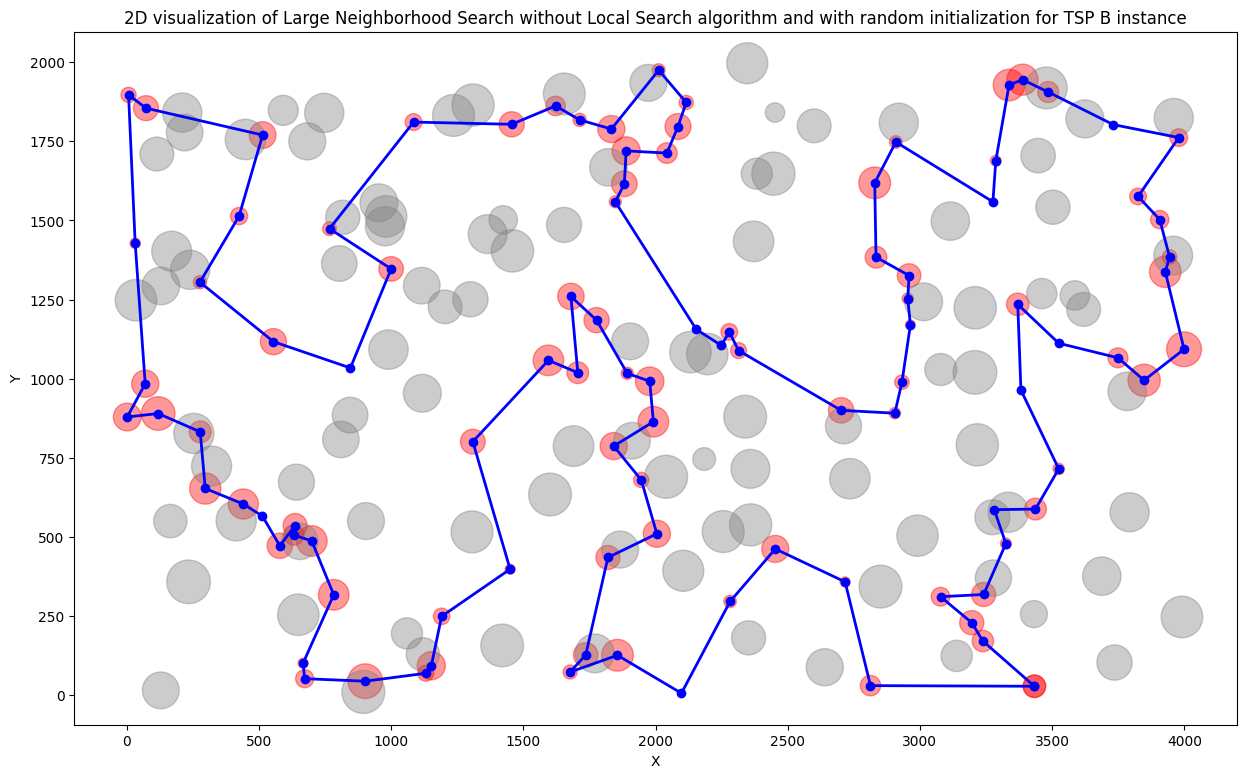

In [31]:
instances = [
    (tsp_a, tsp_a_LNS_with_LS, '2D visualization of Large Neighborhood Search with Local Search algorithm and random initialization for TSP A instance'),
    (tsp_a, tsp_a_LNS_no_LS, '2D visualization of Large Neighborhood Search without Local Search algorithm and with random initialization for TSP A instance'),
    (tsp_b, tsp_b_LNS_with_LS, '2D visualization of Large Neighborhood Search with Local Search algorithm and random initialization for TSP B instance'),
    (tsp_b, tsp_b_LNS_no_LS, '2D visualization of Large Neighborhood Search without Local Search algorithm and with random initialization for TSP B instance'),
]
for i in instances:
    plot_tsp(*i)

## **5. Display of the results** ##

### **5.1. TSP A instance** ###
#### **5.1.1. Large Neighborhood Search with Local Search solution** ####

In [27]:
tsp_a_LNS_with_LS

array([196,  81,  90,  27,  71, 164,   7,  95,  39, 165,  40, 185, 106,
       178,  52,  55,  57, 129,  92, 179, 145,  78,  31,  56, 113, 175,
       171,  16,  25,  44, 120,   2, 152,  97,   1, 101,  75,  86,  26,
       100, 121,  53, 180, 154, 135,  70, 127, 123, 162, 133, 151,  51,
       118,  59,  65, 116,  43,  42, 184, 177,  54,  48, 160,  34, 181,
       146,  22,  18, 108,  69, 159, 193,  41, 115, 139,  46,  68, 140,
        93, 117,   0, 143, 183,  89, 186,  23, 137, 176,  80,  79,  63,
        94, 124, 148,   9,  62, 102,  49,  14, 144, 196])

#### **5.1.2. Large Neighborhood Search without Local Search solution** ####

In [28]:
tsp_a_LNS_no_LS

array([112,   4,  84,  35, 184, 177,  54,  48, 160,  34, 181,  42,  43,
       116,  65,  59, 118, 115,  46,  68, 139,  41, 193, 159, 146,  22,
        18, 108, 140,  93, 117,   0, 143, 183,  89,  23, 137, 176,  80,
        51, 151, 162, 133,  79,  63,  94, 124, 148,   9,  62, 144,  14,
        49, 178, 106,  52,  55,  57, 129,  92,  78, 145, 179, 185,  40,
       165,  39,  95,   7, 164,  71,  27,  90,  81, 196, 157,  31, 113,
       175, 171,  16,  25,  44, 120,   2, 152,  97,   1, 101,  75,  86,
        26, 121,  53, 180, 154, 135,  70, 127, 123, 112])

### **5.2. TSP B instance** ###

#### **5.2.1. Large Neighborhood Search with Local Search solution** ####

In [29]:
tsp_b_LNS_with_LS

array([155,   3,  70,  15, 145, 195, 168,  13, 132, 169, 188,   6, 147,
        90,  51, 121, 131, 135, 122, 133, 107,  40,  63,  38,  27,  16,
         1, 156, 198, 117, 193,  31,  54,  73, 136, 190,  80, 162, 175,
        78,   5, 177,  36,  61,  91, 141,  77,  81, 153, 187, 163,  89,
       127, 103, 113, 176, 194, 166,  86, 185,  95, 130,  99,  22, 179,
        66,  94,  47, 148,  60,  20,  28, 149,   4, 140, 183, 152, 170,
        34,  55,  18,  62, 124, 106, 143,  35, 109,   0,  29, 111,  82,
        21,   8, 104, 144, 160,  33, 138,  11, 139, 155])

#### **5.2.2. Large Neighborhood Search without Local Search solution** ####

In [30]:
tsp_b_LNS_no_LS

array([137, 127,  89, 163, 103, 113, 176, 194, 166,  86,  95, 185, 179,
       172,  57,  66,  94,  47, 148,  60,  20,  28, 149,   4, 140, 183,
       152, 170,  34,  55,  18,  62, 124, 106, 143,  35, 109,   0,  29,
       168, 195,  13, 145,  15,   3,  70, 132, 169, 188,   6, 147,  90,
        51, 121, 131, 135, 122, 133, 107,  40,  63,  38,  27,  16,   1,
       156, 198, 117, 193,  54,  31,  73, 136, 190,  80, 162, 175,  78,
         5, 177,  25, 182, 138, 139,  11,  33, 160, 144, 104,   8,  82,
        21,  61,  36,  91, 141,  77,  81, 153, 187, 137])

## **6. Usage of solution checker**

Solution checker was used for all computed above solutions and value of objective functions are correct.

## **7. Link to the source code** ##

https://github.com/WojtekNagorka/Evolutionary-computation/tree/main/lab7

## **8. Conclusions**

### **TODO**:
1. cos o tym, ze z LS jest lepiej
2. cos o tym ze bez LS mniej iteracji
3. cos o tym ze LNS+LS jest lepsze od klasycznego LS